In [1]:
import torch
import torch.nn as nn
import numpy as np
import platform

# Set random seeds
SEED = 35
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============ ARCHITECTURE CONFIGURATION ============
# Switch between M2 Mac (ARM64) and AMD (x86_64) by changing DEVICE_TYPE
# Options: 'mps' (Apple M-series), 'cuda' (NVIDIA GPU), 'cpu'
#DEVICE_TYPE = 'mps'  # M2 Mac
DEVICE_TYPE = 'cuda'  # AMD with NVIDIA GPU
# DEVICE_TYPE = 'cpu'  # Fallback for any architecture

if DEVICE_TYPE == 'mps' and platform.system() == 'Darwin':
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
elif DEVICE_TYPE == 'cuda':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")
# =====================================================

Using device: cuda


# Distributed Model Poisoning Attack (Milestone 3)

Multiple coordinating adversarial clients decompose the targeted-poisoning objective across their respective updates. This notebook supports three attack modes via the `ATTACK_MODE` config flag:

1. **`naive`** — each adversary independently runs the same vanilla attack on its own disjoint aux subset, then PGD-projects to a fixed radius. This is the natural "f attackers in parallel" baseline.
2. **`coordinated`** — a `CoordinatedAttackPlanner` computes a single shadow target boosted-delta δ once per round (training a shadow attacker on the *full* auxiliary data), then partitions δ across the f adversaries by parameter-index stripe. Each adversary submits an update modifying only its assigned ~1/f of parameters. The aggregate of all f selected adversaries reconstructs δ, but each adversary's individual update is *orthogonal in parameter space* to the others — high pairwise cosine distance between adversaries, defeating sybil-clustering defenses (FoolsGold-style) that rely on "malicious clients submit similar updates."
3. **`adaptive`** — same coordinated decomposition, but the PGD radius is set per-round to ~2× the median honest update norm from the previous round (EMA-smoothed), so adversaries automatically blend into the honest band as it drifts during training.

Modes 2 and 3 are the project's actual contribution beyond Bhagoji et al.'s multi-attacker setup (which scales the boost by 1/f but keeps every adversary on the same direction, so they cluster trivially).

## Prerequisites

- `./models/fedavg_resnet18_baseline.pth` — produced by `Baseline.ipynb`
- `./histories/baseline.json` — produced by `Baseline.ipynb`
- `./histories/poisoned.json` — produced by `Poisoned.ipynb`
- Tiny ImageNet 200 dataset

## Outputs

- `./models/fedavg_resnet18_distributed.pth`
- `./histories/distributed.json` (config records the `attack_mode` used)
- 3-way comparison plots in `./figures/`

## Run order

1. `Baseline.ipynb`
2. `Poisoned.ipynb`
3. **This notebook** — set `ATTACK_MODE` in cell 8 to one of `'naive'`, `'coordinated'`, or `'adaptive'`. Default is `'adaptive'`.

To compare modes, re-run with different `ATTACK_MODE` values and rename `histories/distributed.json` between runs (e.g., to `distributed_naive.json`, `distributed_coordinated.json`, `distributed_adaptive.json`).

## Configuration

- **Attack:** Source class = 0, Target class = 50, f = 3 adversaries, boost = 10×
- **PGD:** Initial radius = 10.0; in adaptive mode this drifts toward 2× median honest norm
- **Federation:** K=30, m=6, R=25, E=8 (matches Baseline and Poisoned)
- **Threat model:** Same as Poisoned — attack runs against the converged baseline model

## Compute cost note

Coordinated and adaptive modes train a shadow attacker once per round (only on the auxiliary data, no honest training), adding ~30–50% to per-round wall-clock vs. naive mode. This is the cost of the coordination mechanism.

---

# Dataset Gathering

We assume you have a Tiny ImageNet dataset already extracted (see `Baseline.ipynb` for first-time setup).


In [2]:
import os, shutil
#Preprocessing
val_dir = "tiny-imagenet-200/val"
img_dir = os.path.join(val_dir, "images")
anno_file = os.path.join(val_dir, "val_annotations.txt")



"""with open(anno_file) as f:
    for line in f:
        img, cls = line.split("\t")[:2]
        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
        shutil.move(
            os.path.join(img_dir, img),
            os.path.join(val_dir, cls, img)
        )"""

'with open(anno_file) as f:\n    for line in f:\n        img, cls = line.split("\t")[:2]\n        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)\n        shutil.move(\n            os.path.join(img_dir, img),\n            os.path.join(val_dir, cls, img)\n        )'

In [3]:
from torchvision import transforms, datasets
#Transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
#For later display of the image:
unnormalize = transforms.Normalize(
    mean = [-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std = [1/s for s in [0.229, 0.224, 0.225]]
)

#Load dataset
train_dataset = datasets.ImageFolder(
    root='./tiny-imagenet-200/train',
    transform=transform_train
)
test_dataset = datasets.ImageFolder(
    root='./tiny-imagenet-200/val',
    transform=transform_val
)

In [4]:
import matplotlib.pyplot as plt

def find_and_display_matching_images(train_ds, test_ds, label_num):
    train_image = None
    train_label = None
    test_image = None

    # Find a sample from the training dataset
    for i in range(len(train_ds)):
        train_image, train_label = train_ds[i]
        if train_label != label_num:
          continue
        for j in range(len(test_ds)):
            test_img, test_lbl = test_ds[j]
            if train_label == test_lbl:
                test_image = test_img
                break
        if test_image is not None: # Found a match
            break

    if test_image is not None:
        # Unnormalize and convert to PIL Image for display
        pil_train_img = transforms.functional.to_pil_image(unnormalize(train_image))
        pil_test_img = transforms.functional.to_pil_image(unnormalize(test_image))

        # Display images
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(pil_train_img)
        axes[0].set_title(f"Train Image (Label: {train_label})")
        axes[0].axis('off')

        axes[1].imshow(pil_test_img)
        axes[1].set_title(f"Test Image (Label: {train_label})")
        axes[1].axis('off')

        plt.show()


find_and_display_matching_images(train_dataset, test_dataset, 2)

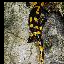

In [5]:
transforms.functional.to_pil_image(unnormalize(train_dataset[999][0]))

In [6]:
#Create dataloader (we have to partition the train dataloader later):
from torch.utils.data import DataLoader, Subset

# ============ PLATFORM-SPECIFIC DATALOADER CONFIG ============
# macOS and Windows need num_workers=0 to avoid multiprocessing issues
# Linux/AMD can use higher values for performance
PLATFORM_WORKERS = 0 if platform.system() in ['Darwin', 'Windows'] else 4
# ===========================================================

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=PLATFORM_WORKERS)

# Federated Learning Parameters

In [7]:
# ============ FAST MODE vs PRODUCTION MODE ============
# Switch FAST_MODE to True for quick testing (minutes), False for full training (hours)
# **IMPORTANT: Must match Baseline.ipynb and Poisoned.ipynb FAST_MODE value for metrics to align**
FAST_MODE = False
# ====================================================

if FAST_MODE:
    # ===== FAST TEST CONFIG (should run in ~5-8 minutes) =====
    NUM_CLIENTS = 4                  # Down from 30
    NUM_CLIENTS_PER_ROUND = 2        # Down from 6
    NUM_ROUNDS = 3                   # Down from 25
    LOCAL_EPOCHS = 1                 # Down from 8
    BATCH_SIZE = 64                  # Down from 128
    LEARNING_RATE = 0.01
    MOMENTUM = 0.9
    DIRICHLET_ALPHA = 0.5
    NUM_AUX_SAMPLES = 10             # Down from 100
    print("⚡ FAST MODE: Minimal viable test (expect ~5-8 min)")
else:
    # ===== PRODUCTION CONFIG (full training, ~2-3 hours) =====
    NUM_CLIENTS = 30
    NUM_CLIENTS_PER_ROUND = 6
    NUM_ROUNDS = 25
    LOCAL_EPOCHS = 8
    BATCH_SIZE = 128
    LEARNING_RATE = 0.01
    MOMENTUM = 0.9
    DIRICHLET_ALPHA = 0.5
    NUM_AUX_SAMPLES = 100
    print("🚀 PRODUCTION MODE: Full training (expect ~2-3 hours)")

print(f"   Clients: {NUM_CLIENTS} | Per round: {NUM_CLIENTS_PER_ROUND} | Rounds: {NUM_ROUNDS} | Epochs: {LOCAL_EPOCHS}")

# Poisoning hyperparameters (match Baseline and Poisoned)
SOURCE_CLASS = 0
TARGET_CLASS = 50
BOOST_FACTOR = 10.0

# Distributed-attack-specific hyperparameters
NUM_ADVERSARIES = 3       # f: number of coordinating adversarial clients
INITIAL_PGD_RADIUS = 10.0 # initial L2-norm cap on each adversary's chunk

# Attack mode: 'naive', 'coordinated', or 'adaptive'
#   'naive':       each adversary independently attacks its own aux subset (no coordination)
#   'coordinated': shared shadow delta partitioned across adversaries (option 2)
#   'adaptive':    coordinated + PGD radius tracks median honest norm (option 3, recommended)
ATTACK_MODE = 'naive'

# Adaptive-mode-specific: target multiplier of median honest norm, EMA factor
ADAPTIVE_TARGET_MULT = 2.0  # PGD radius -> 2x median honest norm
ADAPTIVE_EMA_ALPHA = 0.5    # 0=no adaptation, 1=instant snap to target

assert ATTACK_MODE in ('naive', 'coordinated', 'adaptive')
print(f"Attack mode: {ATTACK_MODE}")

🚀 PRODUCTION MODE: Full training (expect ~2-3 hours)
   Clients: 30 | Per round: 6 | Rounds: 25 | Epochs: 8
Attack mode: naive


# IID Dataset generation

In [8]:
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

#Divide the training dataset into clients for later use with the Dirichlet distribution

print(f"Clients: {NUM_CLIENTS}. ")
def divide_training_dataset(dataset, num_clients, alpha):
  """
  Returns a list of dataloaders dividing the training dataset into num_clients
  portions"""
  rng = np.random.default_rng(SEED + 1)
  num_classes = len(dataset.class_to_idx)
  samples_per_client = int(len(dataset) / num_clients)
  # Organize by class
  class_indices = defaultdict(list)
  for idx, label in enumerate(dataset.targets):
      class_indices[label].append(idx)

  print(f"Initial class sample counts: {[len(v) for k, v in class_indices.items()]}")

  client_dataloaders = []
  #Client data loop
  for client_id in range(num_clients):
    client_indicies = []
    #Data porpotions
    proportions = rng.dirichlet(np.ones(num_classes) * alpha)
    #This is an element wise multiplication: each element of proportions is multiplied by samples_per_client
    client_samples = samples_per_client  * proportions
    client_samples = np.floor(client_samples).astype(int)

    #Gather each class seperately
    for class_id in range(num_classes):
      available = class_indices[class_id]
      num_to_select = min(client_samples[class_id], len(available))
      #We need to make sure we actually have the samples available for use
      if num_to_select > 0:
        selected = rng.choice(available, num_to_select, replace=False)
        #Remove selected indicies from available ones
        class_indices[class_id] = list(set(available) - set(selected))
        client_indicies.extend(selected)
    #Finally we just pack each dataset subset into a dataloader
    client_dataloaders.append(DataLoader(Subset(dataset, client_indicies), batch_size=BATCH_SIZE, shuffle=True, num_workers=PLATFORM_WORKERS))
    print(f"Finished with client: {client_id}. Number of samples: {len(client_indicies)}\n", end="")

  #Anything remaining goes into a holdout dataset for future use.
  remaining_indicies = []
  for class_id in range(num_classes):
    remaining_indicies.extend(class_indices[class_id])
  holdout_dataset = Subset(dataset, remaining_indicies)



  return client_dataloaders, holdout_dataset

client_dataloaders, holdout_dataset = divide_training_dataset(train_dataset, NUM_CLIENTS, DIRICHLET_ALPHA)

Clients: 30. 
Initial class sample counts: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 5

In [9]:
# Auxiliary dataset for poisoning.
#   - aux_full_dataloader: complete aux set (used by the shadow attacker in coordinated/adaptive modes)
#   - aux_subset_dataloaders: list of NUM_ADVERSARIES disjoint subsets (used in naive mode)
def get_aux_indicies_for_class(dataset, class_label, max_samples):
    indicies = np.where(np.array(dataset.targets) == class_label)[0]
    if max_samples > 0:
        indicies = indicies[:max_samples]
    return indicies

aux_indicies = get_aux_indicies_for_class(train_dataset, SOURCE_CLASS, NUM_AUX_SAMPLES)
print(f"Total auxiliary samples: {len(aux_indicies)}")

aux_full_dataloader = DataLoader(
    Subset(train_dataset, list(aux_indicies)), batch_size=BATCH_SIZE, shuffle=True, num_workers=PLATFORM_WORKERS
)

def partition_indicies(indicies, num_partitions):
    """Stripe-partition: indicies[i::num_partitions]. Disjoint by construction."""
    indicies = np.array(indicies)
    return [indicies[i::num_partitions] for i in range(num_partitions)]

aux_partitions = partition_indicies(aux_indicies, NUM_ADVERSARIES)
aux_subset_dataloaders = [
    DataLoader(Subset(train_dataset, list(part)), batch_size=BATCH_SIZE, shuffle=True, num_workers=PLATFORM_WORKERS)
    for part in aux_partitions
]
for i, part in enumerate(aux_partitions):
    print(f"  Adversary {i}: {len(part)} aux samples (subset)")

Total auxiliary samples: 100
  Adversary 0: 34 aux samples (subset)
  Adversary 1: 33 aux samples (subset)
  Adversary 2: 33 aux samples (subset)


# Model

In [10]:
import torchvision.models as models
import copy
def resnet18_tiny_imagenet(num_classes=200):
  model = models.resnet18(weights=None, num_classes=200)
  #TinyImagenet images are 64x64, so we have to change the first layer
  model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
  #Remove the max pooling layer to preserve more spatial information
  model.maxpool = nn.Identity()
  return model
def clone_resnet_model(state_dict, num_classes=200):
  new_model = resnet18_tiny_imagenet(num_classes)
  #Deep copy of state dict to avoid shenanigans
  new_model.load_state_dict(copy.deepcopy(state_dict))
  return new_model

# Federated Client

In [11]:
from tqdm.notebook import tqdm

#Federated Client
class Client:
  def __init__(self, client_id, dataloader):
    self.client_id = client_id
    self.dataloader = dataloader
    self.device = device
    self.model = resnet18_tiny_imagenet()
    self.criterion = nn.CrossEntropyLoss()
    self.is_adversary = False
  def get_state_dict(self):
    return self.model.state_dict()
  def load_state(self, state_dict):
    self.model.load_state_dict(copy.deepcopy(state_dict))
  def get_num_samples(self):
    return len(self.dataloader.dataset)
  def train_step(self, local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, momentum=MOMENTUM, verbose=False):
    """
    Trains locally for n epochs
    Returns the loss, and the l2 between the intial and final state
    """
    intial_state = copy.deepcopy(self.model.state_dict())
    self.model.to(self.device)
    running_loss = 0.0
    optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
    for epoch in tqdm(range(local_epochs), desc="Local Epoch:", leave=False):
      for images, labels in self.dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if verbose:
      print(f"Client {self.client_id} done")
    self.model.to("cpu")
    l2_distance = 0.0
    for key in intial_state:
      if not torch.is_floating_point(intial_state[key]):
        continue
      l2_distance += torch.norm((intial_state[key] - self.model.state_dict()[key]).float()).item()
    return running_loss / len(self.dataloader), l2_distance
  def evaluate(self, test_dataloader, verbose=False):
    """
    Evaluates the model on the test dataset
    """
    criterion = nn.CrossEntropyLoss()
    self.model.to(self.device)
    self.model.eval()
    with torch.no_grad():
      running_loss = 0.0
      correct = 0
      for images, labels in test_dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    if verbose:
      print(f"Client {self.client_id} done")
    self.model.to("cpu")
    return running_loss / len(test_dataloader), correct / len(test_dataloader.dataset)

# Distributed Poisoned Client

A `DistributedPoisonedClient` performs the same per-step pattern as the vanilla `PoisonedClient` (honest training, then aux-data training with target labels, then boost), but with two differences:

1. **Each adversary trains only on its assigned subset of the auxiliary data**, not the full aux set. The poisoning objective is decomposed across f clients.
2. **After boosting, the per-key delta is L2-projected onto a ball of radius `PGD_RADIUS`** around the global model (the "P" in PGD). This caps the magnitude of any single adversary's contribution, regardless of how aggressive the boost is.

The aggregate effect across the f clients (when multiple are selected in the same round) is what pushes the global model — no single update needs to overpower the honest contributions on its own.


# Coordinated Attack Planner

Used in `coordinated` and `adaptive` modes. Once per round, the planner:

1. Trains a **shadow attacker** on the full auxiliary data starting from the current global model state, producing a single boosted target delta `δ`. The shadow does *not* do honest local training — it only computes the adversarial direction. (Each individual adversary still does its own honest training in `train_step` for plausibility.)
2. **Partitions the parameter keys** across the `NUM_ADVERSARIES` adversaries by stripe (`keys[i::f]`). Each adversary is responsible for a non-overlapping ~1/f of the network's parameters.
3. (**Adaptive mode only**) Adjusts the PGD radius for the next round to `ADAPTIVE_TARGET_MULT × median(honest_norms_last_round)`, EMA-smoothed by `ADAPTIVE_EMA_ALPHA`. This makes the adversarial chunk size track the honest band as it drifts during training.

When an adversary's `train_step` is called, it queries the planner for `(target_delta, assigned_keys, current_pgd_radius)`. It applies `w_global + δ[k]` only at its assigned keys (other parameters left unchanged), then PGD-projects the chunk delta to the current radius.

The aggregate of f orthogonal-in-parameter-space chunks reassembles into `δ` after FedAvg averaging — but each adversary's individual update points in a different direction, so cosine-similarity-based defenses (FoolsGold, FLTrust trust scoring) cannot cluster them.


In [12]:
import statistics

class CoordinatedAttackPlanner:
    """Computes a shared shadow boosted-delta per round and partitions it
    across the f adversaries. In adaptive mode, the PGD radius tracks the
    honest band observed in the previous round."""
    def __init__(self, num_adversaries, full_aux_dataloader,
                 source_class, target_class, boost_factor,
                 initial_pgd_radius, mode,
                 adaptive_target_mult=2.0, adaptive_ema_alpha=0.5,
                 partition_strategy='stripe'):
        self.num_adversaries = num_adversaries
        self.full_aux_dataloader = full_aux_dataloader
        self.source_class = source_class
        self.target_class = target_class
        self.boost_factor = float(boost_factor)
        self.current_pgd_radius = float(initial_pgd_radius)
        self.mode = mode  # 'coordinated' or 'adaptive'
        self.adaptive_target_mult = float(adaptive_target_mult)
        self.adaptive_ema_alpha = float(adaptive_ema_alpha)
        self.partition_strategy = partition_strategy
        # Per-round state
        self._round_id = None
        self._global_state = None
        self._server_history = None
        self._cache = None
        # History for diagnostics
        self.pgd_radius_history = []

    # --- Round lifecycle ---

    def set_round(self, round_id, global_state, server_history):
        """Called by the training loop once per round, before any adversary
        runs train_step. Marks the round as needing fresh computation."""
        self._round_id = round_id
        self._global_state = {k: v.clone() for k, v in global_state.items()}
        self._server_history = server_history
        self._cache = None  # invalidate; will be recomputed on first adversary call

    def _adapt_pgd_radius(self):
        """Adaptive mode: set PGD radius from previous round's honest norms."""
        if self.mode != 'adaptive':
            return
        history = self._server_history or {}
        if not history.get('client_norms'):
            return  # round 1, no previous data
        last_norms = history['client_norms'][-1]
        last_is_adv = history['client_is_adversary'][-1]
        honest_norms = [n for n, is_a in zip(last_norms, last_is_adv) if not is_a]
        if not honest_norms:
            return
        median_honest = statistics.median(honest_norms)
        target = self.adaptive_target_mult * median_honest
        # EMA toward target
        self.current_pgd_radius = (
            (1 - self.adaptive_ema_alpha) * self.current_pgd_radius
            + self.adaptive_ema_alpha * target
        )

    def _compute_shadow_delta(self, local_epochs, lr, momentum):
        """Train a shadow attacker on the full aux data (target labels only,
        no honest stage). Returns the boosted delta dict against the cached
        global state."""
        shadow = resnet18_tiny_imagenet()
        shadow.load_state_dict(copy.deepcopy(self._global_state))
        shadow.to(device)
        shadow.train()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(shadow.parameters(), lr=lr, momentum=momentum)
        for _ in range(local_epochs):
            for images, labels in self.full_aux_dataloader:
                attack_labels = torch.full_like(labels, self.target_class)
                images, attack_labels = images.to(device), attack_labels.to(device)
                optimizer.zero_grad()
                outputs = shadow(images)
                loss = criterion(outputs, attack_labels)
                loss.backward()
                optimizer.step()
        shadow.to('cpu')
        # Boosted delta on weight/bias parameters (skip BN running stats)
        delta = {}
        final_state = shadow.state_dict()
        for key in final_state:
            if not torch.is_floating_point(final_state[key]):
                continue
            if not any(k in key for k in ['weight', 'bias']):
                continue
            if 'bn' in key:
                continue
            delta[key] = self.boost_factor * (final_state[key] - self._global_state[key].cpu())
        del shadow
        torch.cuda.empty_cache()
        return delta

    def _partition(self, delta_keys):
        """Stripe-partition the eligible keys across adversaries."""
        keys_sorted = sorted(delta_keys)
        assignments = {i: [] for i in range(self.num_adversaries)}
        for idx, k in enumerate(keys_sorted):
            assignments[idx % self.num_adversaries].append(k)
        return assignments

    def _ensure_prepared(self, local_epochs, lr, momentum):
        if self._cache is not None:
            return
        self._adapt_pgd_radius()
        target_delta = self._compute_shadow_delta(local_epochs, lr, momentum)
        assignments = self._partition(target_delta.keys())
        self._cache = {
            'target_delta': target_delta,
            'assignments': assignments,
            'pgd_radius': self.current_pgd_radius,
        }
        self.pgd_radius_history.append(float(self.current_pgd_radius))

    # --- Adversary-facing API ---

    def get_chunk_for_adversary(self, adversary_idx, local_epochs, lr, momentum):
        self._ensure_prepared(local_epochs, lr, momentum)
        return (
            self._cache['target_delta'],
            self._cache['assignments'][adversary_idx],
            self._cache['pgd_radius'],
        )


In [13]:
class DistributedPoisonedClient(Client):
    """Naive distributed adversary (ATTACK_MODE='naive').
    Trains on its own slice of auxiliary data, boosts, then PGD-projects."""
    def __init__(self, client_id, dataloader, auxiliary_data,
                 source_class=SOURCE_CLASS, target_class=TARGET_CLASS,
                 boost_factor=BOOST_FACTOR, pgd_radius=INITIAL_PGD_RADIUS):
        super().__init__(client_id, dataloader)
        self.is_adversary = True
        self.auxiliary_data = auxiliary_data
        self.source_class = source_class
        self.target_class = target_class
        self.boost_factor = float(boost_factor)
        self.pgd_radius = float(pgd_radius)

    def _delta_norm(self, initial, final):
        total = 0.0
        for key in final:
            if not torch.is_floating_point(final[key]):
                continue
            total += torch.norm((final[key] - initial[key]).float()).item()
        return total

    def train_step(self, local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, momentum=MOMENTUM, verbose=False):
        initial_state = copy.deepcopy(self.model.state_dict())
        self.model.to(self.device)
        running_loss = 0.0
        optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
        for epoch in tqdm(range(local_epochs), desc="Local Epoch:", leave=False):
            for images, labels in self.dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images); loss = self.criterion(outputs, labels)
                loss.backward(); optimizer.step()
                running_loss += loss.item()
        for epoch in tqdm(range(local_epochs), desc="Poisoned Epoch:", leave=False):
            for images, labels in self.auxiliary_data:
                attack_labels = torch.full_like(labels, self.target_class)
                images, attack_labels = images.to(self.device), attack_labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images); loss = self.criterion(outputs, attack_labels)
                loss.backward(); optimizer.step()
                running_loss += loss.item()
        self.model.to("cpu")
        # Boost weight/bias deltas (skip BN)
        final_state = copy.deepcopy(self.model.state_dict())
        for key in final_state:
            if not torch.is_floating_point(final_state[key]): continue
            if not any(k in key for k in ["weight", "bias"]): continue
            if 'bn' in key: continue
            delta = final_state[key] - initial_state[key]
            final_state[key] = initial_state[key] + self.boost_factor * delta
        # PGD project to fixed radius
        boosted_norm = self._delta_norm(initial_state, final_state)
        if boosted_norm > self.pgd_radius and boosted_norm > 0:
            scale = self.pgd_radius / boosted_norm
            for key in final_state:
                if not torch.is_floating_point(final_state[key]): continue
                delta = final_state[key] - initial_state[key]
                final_state[key] = initial_state[key] + scale * delta
        for k, t in final_state.items():
            if torch.is_floating_point(t) and (torch.isnan(t).any() or torch.isinf(t).any()):
                print(f"Bad state on {self.client_id}: {k}")
        l2 = self._delta_norm(initial_state, final_state)
        self.model.load_state_dict(final_state)
        return running_loss / max(1, len(self.dataloader)), l2


class CoordinatedDistributedClient(Client):
    """Coordinated/adaptive distributed adversary.
    Submits w_global + delta restricted to its assigned parameter chunk,
    where delta is the shared shadow boosted-delta from the planner."""
    def __init__(self, client_id, dataloader, planner, adversary_idx):
        super().__init__(client_id, dataloader)
        self.is_adversary = True
        self.planner = planner
        self.adversary_idx = adversary_idx

    def _delta_norm_on_keys(self, initial, final, keys):
        total = 0.0
        for key in keys:
            if key in final and torch.is_floating_point(final[key]):
                total += torch.norm((final[key] - initial[key]).float()).item()
        return total

    def _delta_norm_total(self, initial, final):
        total = 0.0
        for key in final:
            if not torch.is_floating_point(final[key]): continue
            total += torch.norm((final[key] - initial[key]).float()).item()
        return total

    def train_step(self, local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, momentum=MOMENTUM, verbose=False):
        initial_state = copy.deepcopy(self.model.state_dict())
        # Honest local training (preserves plausibility — and the loss reported
        # to the server reflects normal-looking training)
        self.model.to(self.device)
        running_loss = 0.0
        optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
        for epoch in tqdm(range(local_epochs), desc=f"Local (adv {self.adversary_idx}):", leave=False):
            for images, labels in self.dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(images); loss = self.criterion(outputs, labels)
                loss.backward(); optimizer.step()
                running_loss += loss.item()
        self.model.to('cpu')
        # Query the planner for this adversary's chunk
        target_delta, assigned_keys, pgd_radius = self.planner.get_chunk_for_adversary(
            self.adversary_idx, local_epochs, lr, momentum
        )
        # Build final state: start from initial_state (which is == global_state since
        # we just loaded it at round start), apply target delta only on assigned keys.
        # Discards the local training output for assigned keys — that's the price of
        # the coordinated mechanism. Honest training still updates non-assigned keys
        # (e.g. BN running stats) so the per-client loss looks normal.
        final_state = copy.deepcopy(initial_state)
        for k in assigned_keys:
            if k in target_delta:
                # initial_state and target_delta are both on CPU
                final_state[k] = initial_state[k] + target_delta[k]
        # PGD projection on the assigned chunk
        chunk_norm = self._delta_norm_on_keys(initial_state, final_state, assigned_keys)
        if chunk_norm > pgd_radius and chunk_norm > 0:
            scale = pgd_radius / chunk_norm
            for k in assigned_keys:
                if k in final_state and torch.is_floating_point(final_state[k]):
                    delta = final_state[k] - initial_state[k]
                    final_state[k] = initial_state[k] + scale * delta
        # NaN/Inf guard
        for k, t in final_state.items():
            if torch.is_floating_point(t) and (torch.isnan(t).any() or torch.isinf(t).any()):
                print(f"Bad state on adv {self.adversary_idx}: {k}")
        l2 = self._delta_norm_total(initial_state, final_state)
        self.model.load_state_dict(final_state)
        return running_loss / max(1, len(self.dataloader)), l2


In [14]:
class Server:
  def __init__(self, num_clients, client_dataloaders):
    self.num_clients = num_clients
    self.client_dataloaders = client_dataloaders
    self.device = device
    self.global_model = resnet18_tiny_imagenet().to(self.device)
    self.round_history = {
      'test_accuracy': [],
      'avg_update_norm': [],
      'avg_loss': [],
      'selected_clients': [],
      'client_norms': [],         # per-round list of per-client L2 norms
      'client_is_adversary': [],  # per-round list of bools, matched ordering
      'attack_success_rate': [],
    }
  def get_state_dict(self):
    return self.global_model.state_dict()
  def load_state(self, state_dict):
    self.global_model.load_state_dict(copy.deepcopy(state_dict))
  def record_round(self, accuracy, avg_update_norm, avg_loss, selected_clients,
                   client_norms=None, client_is_adversary=None,
                   attack_success_rate=None):
    self.round_history['test_accuracy'].append(float(accuracy))
    self.round_history['avg_update_norm'].append(float(avg_update_norm))
    self.round_history['avg_loss'].append(float(avg_loss))
    self.round_history['selected_clients'].append(selected_clients)
    self.round_history['client_norms'].append(
        [float(n) for n in (client_norms or [])])
    self.round_history['client_is_adversary'].append(
        [bool(b) for b in (client_is_adversary or [])])
    if attack_success_rate is not None:
      self.round_history['attack_success_rate'].append(float(attack_success_rate))
  def get_accuracy_history(self):
    return self.round_history['test_accuracy']
  def get_history(self):
    return self.round_history
  def evaluate(self, test_dataloader):
    """Evaluates the global model on the test dataset. Returns (loss, accuracy)."""
    criterion = nn.CrossEntropyLoss()
    self.global_model.eval()
    with torch.no_grad():
      running_loss = 0.0
      correct = 0
      for images, labels in test_dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.global_model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return running_loss / len(test_dataloader), correct / len(test_dataloader.dataset)
  def aggregate(self, clients):
    """FedAvg algorithm. Each client's state is moved to CPU during aggregation
    to bound GPU memory; the new global state is moved back to GPU after."""
    client_dicts = [{k: v.to('cpu') for k, v in client.get_state_dict().items()} for client in clients]
    new_state_dict = {k: v.to('cpu') for k, v in copy.deepcopy(self.get_state_dict()).items()}
    for key in new_state_dict.keys():
        new_state_dict[key] = sum([s_dict[key] for s_dict in client_dicts]) / len(clients)
    self.load_state({k: v.to(self.device) for k, v in new_state_dict.items()})
  def attack_sucess_rate(self, training_dataset, source_label=SOURCE_CLASS, target_label=TARGET_CLASS):
    """ASR on all training-set images of the source class, evaluated on the
    post-aggregation global model. Returns the fraction predicted as the target class."""
    indicies = np.where(np.array(training_dataset.targets) == source_label)[0]
    attack_dataloader = DataLoader(Subset(training_dataset, indicies), batch_size=BATCH_SIZE, shuffle=False)
    self.global_model.eval()
    with torch.no_grad():
      correct = 0
      for images, labels in attack_dataloader:
          attack_labels = torch.full_like(labels, target_label)
          images, attack_labels = images.to(self.device), attack_labels.to(self.device)
          outputs = self.global_model(images)
          _, predicted = torch.max(outputs.data, 1)
          correct += (predicted == attack_labels).sum().item()
    return correct / len(attack_dataloader.dataset)


# Federated Training loop

In [15]:
from tqdm.notebook import tqdm
import os

# Training loop
print(f"Initializing {NUM_CLIENTS} clients ({NUM_CLIENTS - NUM_ADVERSARIES} honest + {NUM_ADVERSARIES} adversaries)")
print(f"Clients per round: {NUM_CLIENTS_PER_ROUND}. Rounds: {NUM_ROUNDS}")
print(f"Attack mode: {ATTACK_MODE}, initial PGD radius: {INITIAL_PGD_RADIUS}, boost: {BOOST_FACTOR}")

# Build planner if needed
if ATTACK_MODE in ('coordinated', 'adaptive'):
    planner = CoordinatedAttackPlanner(
        num_adversaries=NUM_ADVERSARIES,
        full_aux_dataloader=aux_full_dataloader,
        source_class=SOURCE_CLASS, target_class=TARGET_CLASS,
        boost_factor=BOOST_FACTOR,
        initial_pgd_radius=INITIAL_PGD_RADIUS,
        mode=ATTACK_MODE,
        adaptive_target_mult=ADAPTIVE_TARGET_MULT,
        adaptive_ema_alpha=ADAPTIVE_EMA_ALPHA,
    )
    print(f"Planner instantiated for mode '{ATTACK_MODE}'")
else:
    planner = None

# Build the client list
client_list = []
for id in range(NUM_CLIENTS - NUM_ADVERSARIES):
    client_list.append(Client(id, client_dataloaders[id]))
ADVERSARY_IDS = []
for adv_idx in range(NUM_ADVERSARIES):
    client_id = NUM_CLIENTS - NUM_ADVERSARIES + adv_idx
    ADVERSARY_IDS.append(client_id)
    if ATTACK_MODE == 'naive':
        client_list.append(
            DistributedPoisonedClient(
                client_id,
                client_dataloaders[client_id],
                aux_subset_dataloaders[adv_idx],
            )
        )
    else:  # coordinated or adaptive
        client_list.append(
            CoordinatedDistributedClient(
                client_id,
                client_dataloaders[client_id],
                planner,
                adv_idx,
            )
        )
print(f"Adversary client IDs: {ADVERSARY_IDS}")

server = Server(NUM_CLIENTS, client_dataloaders)

# Load the converged baseline model
baseline_path = "./models/fedavg_resnet18_baseline.pth"
if os.path.exists(baseline_path):
    print(f"Loading baseline model from {baseline_path}")
    state_dict = torch.load(baseline_path, map_location=device)
    server.load_state(state_dict)
else:
    raise FileNotFoundError(
        f"Baseline model not found at {baseline_path}. "
        "Run Baseline.ipynb to completion before running this notebook."
    )

seen_clients = set()
outer_bar = tqdm(range(NUM_ROUNDS))
for round in outer_bar:
    outer_bar.set_description(
        f"Round {round + 1} Last 3 acc: {[f'{a:.3f}' for a in server.get_accuracy_history()[-3:]]}"
    )
    global_state = server.get_state_dict()

    # Set up planner for this round (no-op if naive)
    if planner is not None:
        planner.set_round(round, global_state, server.get_history())

    # Select active clients
    active_clients = np.random.choice(client_list, NUM_CLIENTS_PER_ROUND, replace=False)
    round_loss = 0.0
    round_update_norm = 0.0
    client_norms_round = []
    client_is_adv_round = []

    bar = tqdm(enumerate(active_clients), leave=False, total=len(active_clients))
    for idx, chosen_client in bar:
        bar.set_description(
            f"Client {chosen_client.client_id} | size: {chosen_client.get_num_samples()} | adv: {chosen_client.is_adversary}"
        )
        seen_clients.add(chosen_client.client_id)
        chosen_client.load_state(global_state)
        client_loss, client_norm = chosen_client.train_step()
        round_loss += client_loss
        round_update_norm += client_norm
        client_norms_round.append(client_norm)
        client_is_adv_round.append(chosen_client.is_adversary)
        # ============ DEVICE-AWARE CLEANUP ============
        # Only call CUDA functions if using CUDA
        if device.type == 'cuda':
          torch.cuda.synchronize()
          torch.cuda.empty_cache()
        # =============================================

    server.aggregate(active_clients)
    attack_success_rate = server.attack_sucess_rate(train_dataset)

    for name, param in server.global_model.named_parameters():
        if torch.isnan(param).any():
            print(f"NaN detected in parameter: {name}")
            break

    loss, accuracy = server.evaluate(test_loader)
    server.record_round(
        accuracy=accuracy,
        avg_update_norm=round_update_norm / NUM_CLIENTS_PER_ROUND,
        avg_loss=round_loss / NUM_CLIENTS_PER_ROUND,
        selected_clients=[c.client_id for c in active_clients],
        client_norms=client_norms_round,
        client_is_adversary=client_is_adv_round,
        attack_success_rate=attack_success_rate,
    )
    n_adv_selected = sum(client_is_adv_round)
    if n_adv_selected > 0:
        postfix = {'adv': n_adv_selected, 'asr': f"{attack_success_rate:.3f}"}
        if planner is not None:
            postfix['pgd'] = f"{planner.current_pgd_radius:.2f}"
        outer_bar.set_postfix(**postfix)
    if device.type == 'cuda':
      torch.cuda.empty_cache()

Initializing 30 clients (27 honest + 3 adversaries)
Clients per round: 6. Rounds: 25
Attack mode: naive, initial PGD radius: 10.0, boost: 10.0


Adversary client IDs: [27, 28, 29]
Loading baseline model from ./models/fedavg_resnet18_baseline.pth


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

...

Poisoned Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Poisoned Epoch::   0%|          | 0/8 [00:00<?, ?it/s]

Model Saving

In [16]:
if not (os.path.exists("./models")):
    os.mkdir("./models")
torch.save(server.global_model.state_dict(), "./models/fedavg_resnet18_distributed.pth")


In [17]:
import json
if not (os.path.exists("./histories")):
    os.mkdir("./histories")

distributed_data = {
    'config': {
        'run_type': 'distributed',
        'attack_mode': ATTACK_MODE,
        'num_clients': NUM_CLIENTS,
        'num_clients_per_round': NUM_CLIENTS_PER_ROUND,
        'num_rounds': NUM_ROUNDS,
        'local_epochs': LOCAL_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'momentum': MOMENTUM,
        'dirichlet_alpha': DIRICHLET_ALPHA,
        'seed': SEED,
        'source_class': SOURCE_CLASS,
        'target_class': TARGET_CLASS,
        'num_aux_samples': NUM_AUX_SAMPLES,
        'boost_factor': BOOST_FACTOR,
        'num_adversaries': NUM_ADVERSARIES,
        'adversary_ids': ADVERSARY_IDS,
        'initial_pgd_radius': INITIAL_PGD_RADIUS,
        'adaptive_target_mult': ADAPTIVE_TARGET_MULT if ATTACK_MODE == 'adaptive' else None,
        'adaptive_ema_alpha':   ADAPTIVE_EMA_ALPHA if ATTACK_MODE == 'adaptive' else None,
        'partition_strategy':   'stripe' if ATTACK_MODE in ('coordinated', 'adaptive') else None,
        'loaded_baseline':      True,
    },
    'metrics': server.get_history(),
}

# If a planner was used, attach its PGD radius history
if planner is not None:
    distributed_data['metrics']['pgd_radius_history'] = [
        float(x) for x in planner.pgd_radius_history
    ]

m = distributed_data['metrics']
m['test_accuracy']        = [float(x) for x in m['test_accuracy']]
m['avg_update_norm']      = [float(x) for x in m['avg_update_norm']]
m['avg_loss']             = [float(x) for x in m['avg_loss']]
m['attack_success_rate']  = [float(x) for x in m['attack_success_rate']]
m['client_norms']         = [[float(n) for n in row] for row in m['client_norms']]
m['client_is_adversary']  = [[bool(b) for b in row] for row in m['client_is_adversary']]

with open("./histories/distributed.json", "w") as f:
    json.dump(distributed_data, f, indent=2)

print(f"Mode: {ATTACK_MODE}")
print(f"Final test accuracy: {m['test_accuracy'][-1]:.4f}")
print(f"Final ASR: {m['attack_success_rate'][-1]:.4f}")
if planner is not None:
    print(f"Final PGD radius: {planner.current_pgd_radius:.2f}")
print(f"Saved metrics to ./histories/distributed.json")


Mode: naive
Final test accuracy: 0.0068
Final ASR: 0.0100
Saved metrics to ./histories/distributed.json


Pyplot Figures

In [18]:
def plot_training_curves(history):
    #Plot test accuracy, update norm, and loss curves
    fix, axes = plt.subplots(1, 3, figsize=(18, 5))
    #axes[0] is the test accuracy curve
    axes[0].plot(history['test_accuracy'])
    axes[0].set_title("Test Accuracy")
    axes[0].set_xlabel("Round")
    axes[0].set_ylim(0, 1)
    #Axes 1 is the update norm plot
    axes[1].plot(history['avg_update_norm'])
    axes[1].set_title("Average Update Norm")
    axes[1].set_xlabel("Round")
    #Axes 2 is the loss plot
    axes[2].plot(history['avg_loss'])
    axes[2].set_title("Average Client Loss")
    axes[2].set_xlabel("Round")
    plt.tight_layout()
    plt.show()

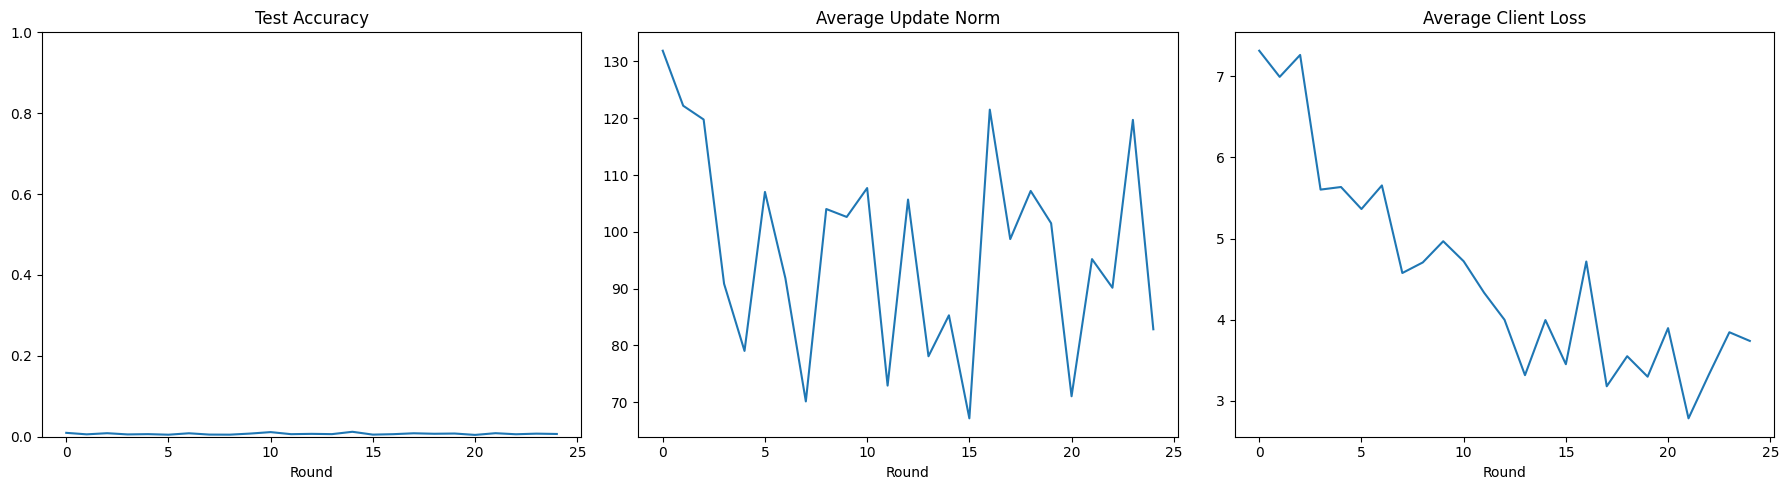

In [19]:
plot_training_curves(server.get_history())

---

# Comparison: Baseline vs. Vanilla (M2) vs. Distributed (M3)

The cells below load `./histories/baseline.json`, `./histories/poisoned.json`, and `./histories/distributed.json` and produce three-way comparisons:

1. **Overlay plot** — clean accuracy, ASR, and update norm across all three runs
2. **Stealth scatter** — per-client update norms with vanilla and distributed adversaries highlighted on the same axes. This is the headline plot for the "stealth-by-decomposition" claim: distributed adversaries blend into the honest band where the vanilla adversary spikes far above it.

Re-run these cells after re-running training to refresh the figures.

In [20]:
import json
import os

paths = {
    'baseline':    './histories/baseline.json',
    'poisoned':    './histories/poisoned.json',
    'distributed': './histories/distributed.json',
}
for name, path in paths.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Run the corresponding notebook first.")

runs = {}
for name, path in paths.items():
    with open(path) as f:
        runs[name] = json.load(f)

dist_mode = runs['distributed']['config'].get('attack_mode', 'unknown')
print(f"{'Run':<24}{'Rounds':<10}{'Final acc':<12}{'Final ASR':<12}{'Adversaries'}")
for name, run in runs.items():
    cfg = run['config']
    m = run['metrics']
    n_adv = cfg.get('num_adversaries', 1 if name == 'poisoned' else 0)
    asr = f"{m.get('attack_success_rate', [0])[-1]:.4f}" if m.get('attack_success_rate') else 'n/a'
    label = name if name != 'distributed' else f"distributed ({dist_mode})"
    print(f"{label:<24}{cfg['num_rounds']:<10}{m['test_accuracy'][-1]:<12.4f}{asr:<12}{n_adv}")


Run                     Rounds    Final acc   Final ASR   Adversaries
baseline                25        0.0059      n/a         0
poisoned                25        0.0001      0.0000      1
distributed (naive)     25        0.0068      0.0100      3


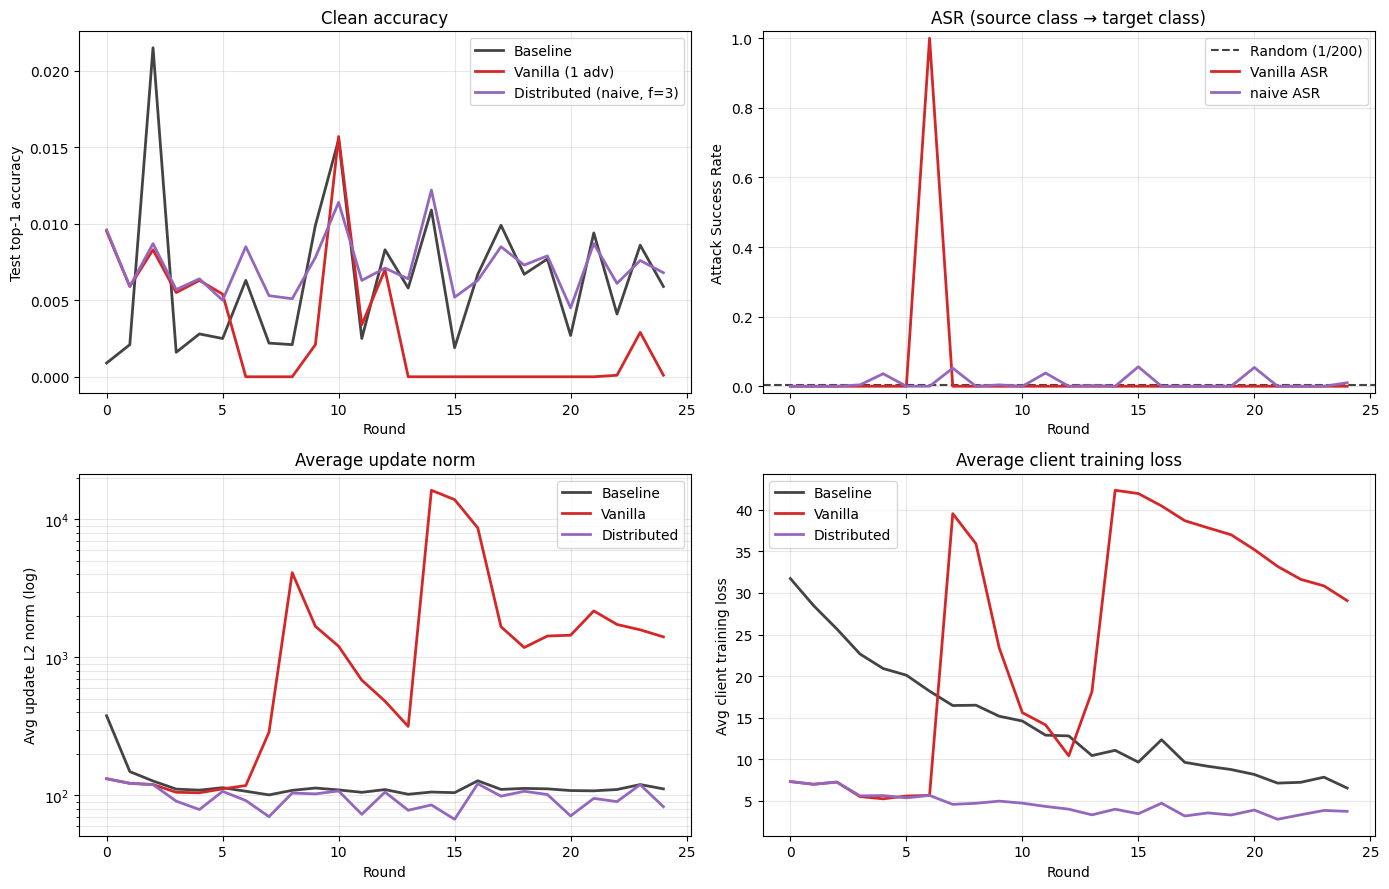

Saved ./figures/three_way_overlay.pdf and .png


In [21]:
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
b = runs['baseline']['metrics']
v = runs['poisoned']['metrics']
d = runs['distributed']['metrics']
dist_mode = runs['distributed']['config'].get('attack_mode', 'unknown')
dist_label = f'Distributed ({dist_mode}, f={runs["distributed"]["config"]["num_adversaries"]})'

# Clean accuracy
ax = axes[0, 0]
ax.plot(b['test_accuracy'], label='Baseline', color='#444444', linewidth=2)
ax.plot(v['test_accuracy'], label='Vanilla (1 adv)', color='#d62728', linewidth=2)
ax.plot(d['test_accuracy'], label=dist_label, color='#9467bd', linewidth=2)
ax.set_xlabel('Round'); ax.set_ylabel('Test top-1 accuracy')
ax.set_title('Clean accuracy'); ax.grid(alpha=0.3); ax.legend()

# ASR
ax = axes[0, 1]
ax.axhline(1/200, color='#444444', linestyle='--', linewidth=1.5, label=f'Random (1/200)')
ax.plot(v['attack_success_rate'], label='Vanilla ASR', color='#d62728', linewidth=2)
ax.plot(d['attack_success_rate'], label=f'{dist_mode} ASR', color='#9467bd', linewidth=2)
ax.set_xlabel('Round'); ax.set_ylabel('Attack Success Rate')
ax.set_title('ASR (source class → target class)')
ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3); ax.legend()

# Round-mean update norm (log-y)
ax = axes[1, 0]
ax.plot(b['avg_update_norm'], label='Baseline', color='#444444', linewidth=2)
ax.plot(v['avg_update_norm'], label='Vanilla', color='#d62728', linewidth=2)
ax.plot(d['avg_update_norm'], label='Distributed', color='#9467bd', linewidth=2)
# In adaptive mode, overlay the PGD radius trajectory
if 'pgd_radius_history' in d and d['pgd_radius_history']:
    ax.plot(d['pgd_radius_history'], label=f'PGD radius ({dist_mode})',
            color='#9467bd', linewidth=1.5, linestyle=':')
ax.set_xlabel('Round'); ax.set_ylabel('Avg update L2 norm (log)')
ax.set_title('Average update norm')
ax.set_yscale('log'); ax.grid(alpha=0.3, which='both'); ax.legend()

# Avg client loss
ax = axes[1, 1]
ax.plot(b['avg_loss'], label='Baseline', color='#444444', linewidth=2)
ax.plot(v['avg_loss'], label='Vanilla', color='#d62728', linewidth=2)
ax.plot(d['avg_loss'], label='Distributed', color='#9467bd', linewidth=2)
ax.set_xlabel('Round'); ax.set_ylabel('Avg client training loss')
ax.set_title('Average client training loss'); ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
if not os.path.exists("./figures"): os.mkdir("./figures")
plt.savefig("./figures/three_way_overlay.pdf", bbox_inches='tight')
plt.savefig("./figures/three_way_overlay.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ./figures/three_way_overlay.pdf and .png")


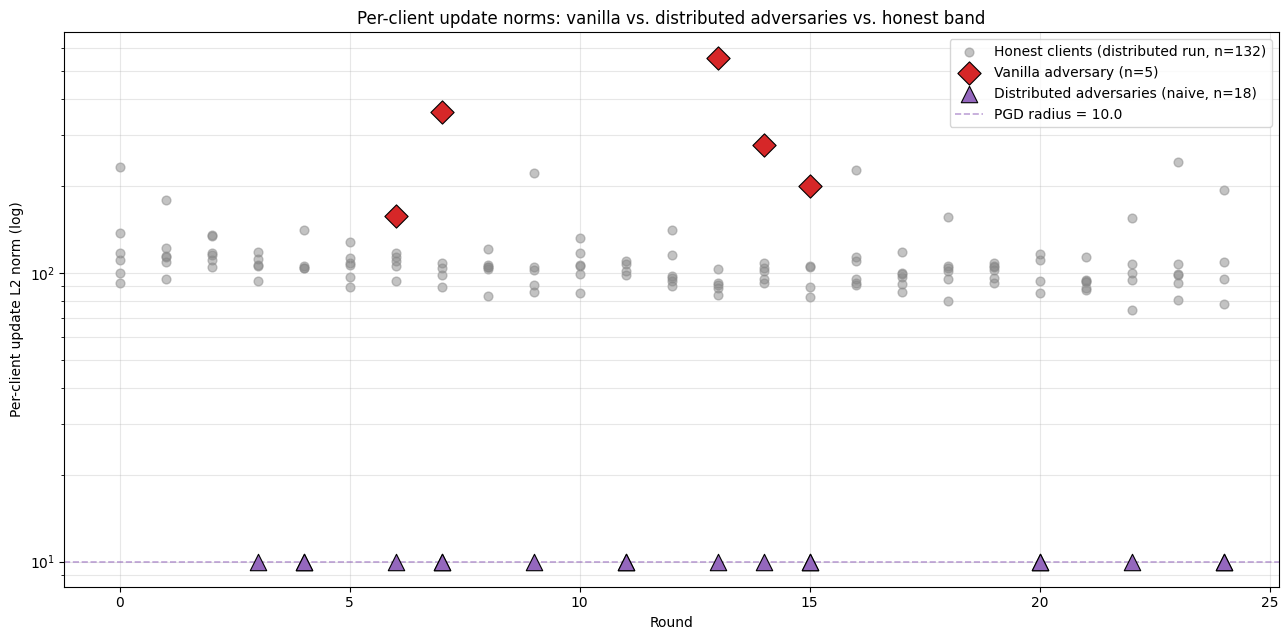

Saved ./figures/stealth_three_way.pdf and .png

Honest clients (distributed run):   median norm = 104.19
Vanilla adversary:                  median norm = 277.10 (n=5)
Distributed adversaries:            median norm = 10.00 (n=18)


In [22]:
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(13, 6.5))

honest_x, honest_y = [], []
dist_adv_x, dist_adv_y = [], []
for r, (norms, is_adv) in enumerate(zip(
        runs['distributed']['metrics']['client_norms'],
        runs['distributed']['metrics']['client_is_adversary'])):
    for norm, adv_flag in zip(norms, is_adv):
        if adv_flag:
            dist_adv_x.append(r); dist_adv_y.append(norm)
        else:
            honest_x.append(r); honest_y.append(norm)

van_adv_x, van_adv_y = [], []
for r, (norms, is_adv) in enumerate(zip(
        runs['poisoned']['metrics']['client_norms'],
        runs['poisoned']['metrics']['client_is_adversary'])):
    for norm, adv_flag in zip(norms, is_adv):
        if adv_flag:
            van_adv_x.append(r); van_adv_y.append(norm)

ax.scatter(honest_x, honest_y, color='#888888', alpha=0.5, s=40,
           label=f'Honest clients (distributed run, n={len(honest_y)})')
if van_adv_x:
    ax.scatter(van_adv_x, van_adv_y, color='#d62728', marker='D', s=140,
               edgecolors='black', linewidths=0.8, zorder=5,
               label=f'Vanilla adversary (n={len(van_adv_x)})')
if dist_adv_x:
    dist_mode = runs['distributed']['config'].get('attack_mode', 'unknown')
    ax.scatter(dist_adv_x, dist_adv_y, color='#9467bd', marker='^', s=140,
               edgecolors='black', linewidths=0.8, zorder=5,
               label=f'Distributed adversaries ({dist_mode}, n={len(dist_adv_x)})')

# PGD radius reference — fixed line for naive/coordinated, trajectory for adaptive
d_metrics = runs['distributed']['metrics']
d_config  = runs['distributed']['config']
if 'pgd_radius_history' in d_metrics and d_metrics['pgd_radius_history']:
    rounds_idx = list(range(len(d_metrics['pgd_radius_history'])))
    ax.plot(rounds_idx, d_metrics['pgd_radius_history'],
            color='#9467bd', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f"PGD radius (adaptive, drifts {d_metrics['pgd_radius_history'][0]:.1f}→{d_metrics['pgd_radius_history'][-1]:.1f})")
else:
    pgd = d_config.get('initial_pgd_radius', 10.0)
    ax.axhline(pgd, color='#9467bd', linestyle='--', linewidth=1.2, alpha=0.6,
               label=f'PGD radius = {pgd:.1f}')

ax.set_xlabel('Round'); ax.set_ylabel('Per-client update L2 norm (log)')
ax.set_title('Per-client update norms: vanilla vs. distributed adversaries vs. honest band')
ax.set_yscale('log'); ax.grid(alpha=0.3, which='both'); ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig("./figures/stealth_three_way.pdf", bbox_inches='tight')
plt.savefig("./figures/stealth_three_way.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ./figures/stealth_three_way.pdf and .png")

import statistics
print()
if honest_y:    print(f"Honest clients (distributed run):   median norm = {statistics.median(honest_y):.2f}")
if van_adv_y:   print(f"Vanilla adversary:                  median norm = {statistics.median(van_adv_y):.2f} (n={len(van_adv_y)})")
if dist_adv_y:  print(f"Distributed adversaries:            median norm = {statistics.median(dist_adv_y):.2f} (n={len(dist_adv_y)})")


---

# Cross-configuration comparison

Overlays **baseline** (clean), **poisoned** (single-adversary boosted from `Poisoned.ipynb`), and the three **distributed** attack modes (`naive`, `coordinated`, `adaptive`) on shared axes. Loads:

- `./histories/baseline.json` (clean reference)
- `./histories/poisoned.json` (single-adversary boosted attack)
- `./histories/distributed_<mode>.json` for any distributed modes already saved (renamed after a prior run)
- The current `./histories/distributed.json` (labelled by its `config['attack_mode']`)

Skips any missing files so this section won't break a partial-mode run.

In [23]:
import json, os

_static_paths = {
    'baseline': './histories/baseline.json',
    'poisoned': './histories/poisoned.json',
}
_dist_mode_paths = {
    'naive':       './histories/distributed_naive.json',
    'coordinated': './histories/distributed_coordinated.json',
    'adaptive':    './histories/distributed_adaptive.json',
}
_current_path = './histories/distributed.json'

all_runs = {}
for _name, _path in _static_paths.items():
    if os.path.exists(_path):
        with open(_path) as _f:
            all_runs[_name] = json.load(_f)
for _mode, _path in _dist_mode_paths.items():
    if os.path.exists(_path):
        with open(_path) as _f:
            all_runs[_mode] = json.load(_f)

if os.path.exists(_current_path):
    with open(_current_path) as _f:
        _cur = json.load(_f)
    _cur_mode = _cur['config'].get('attack_mode', 'current')
    all_runs.setdefault(_cur_mode, _cur)

RUN_ORDER = ['baseline', 'poisoned', 'naive', 'coordinated', 'adaptive']
all_runs = {k: all_runs[k] for k in RUN_ORDER if k in all_runs}

print(f'Runs loaded: {list(all_runs.keys())}')
for _name, _run in all_runs.items():
    _m = _run['metrics']
    _final_asr = _m['attack_success_rate'][-1] if _m.get('attack_success_rate') else float('nan')
    print(f'  {_name}: {len(_m["test_accuracy"])} rounds, final acc {_m["test_accuracy"][-1]:.4f}, final ASR {_final_asr:.4f}')

Runs loaded: ['baseline', 'poisoned', 'naive', 'coordinated', 'adaptive']
  baseline: 25 rounds, final acc 0.0059, final ASR nan
  poisoned: 25 rounds, final acc 0.0001, final ASR 0.0000
  naive: 25 rounds, final acc 0.0068, final ASR 0.0100
  coordinated: 25 rounds, final acc 0.0203, final ASR 0.0120
  adaptive: 25 rounds, final acc 0.0482, final ASR 0.0400


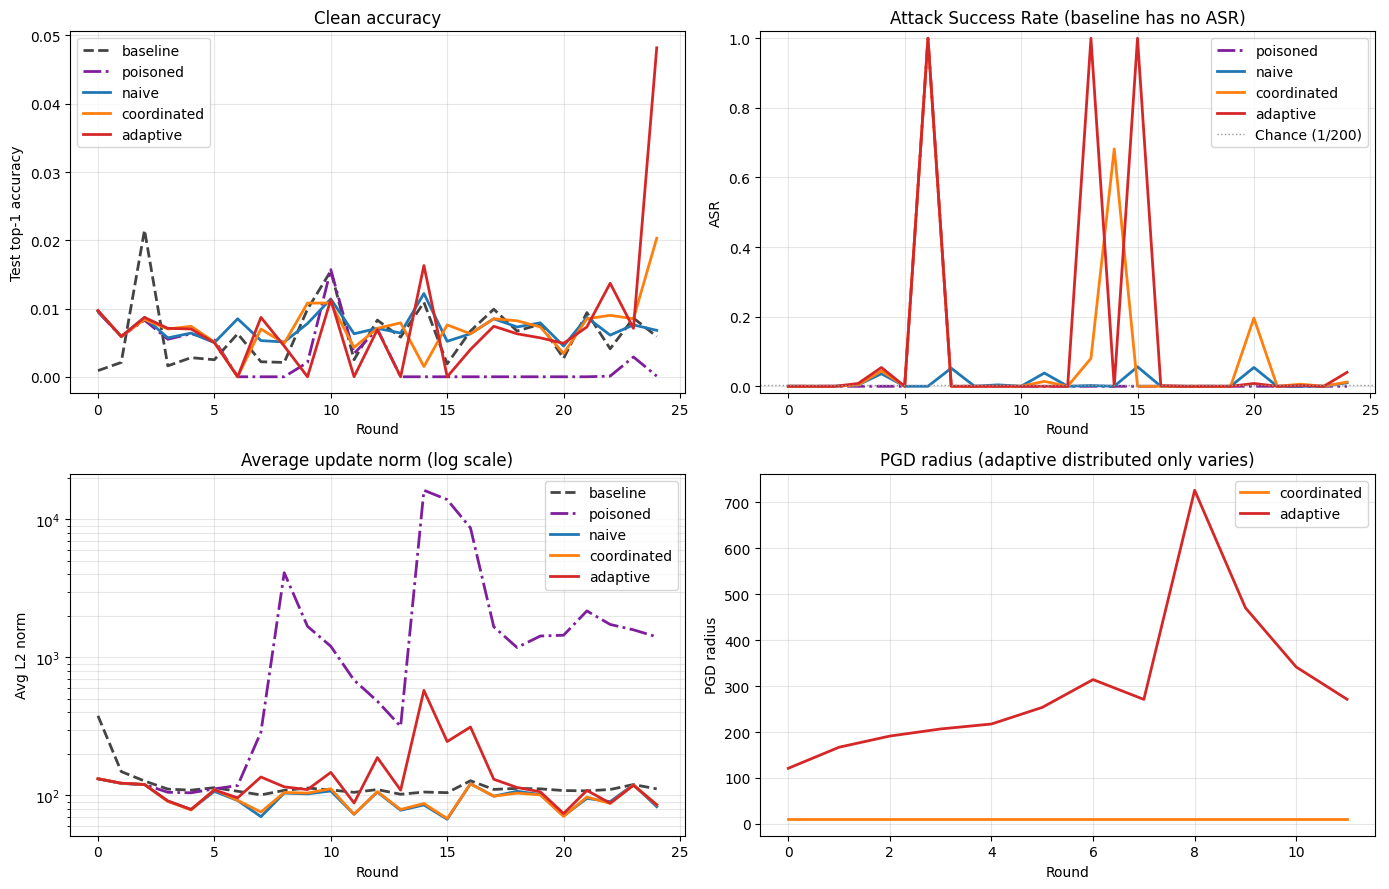

Saved ./figures/distributed_full_overlay.pdf and .png (5 runs)


In [24]:
import matplotlib.pyplot as plt
import os

RUN_COLORS = {
    'baseline':    '#444444',
    'poisoned':    '#7e1e9c',
    'naive':       '#1f77b4',
    'coordinated': '#ff7f0e',
    'adaptive':    '#d62728',
}
RUN_STYLES = {
    'baseline': '--',
    'poisoned': '-.',
}

if not all_runs:
    print('No histories available; skipping overlay.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for _name, _run in all_runs.items():
        _m = _run['metrics']
        _c = RUN_COLORS.get(_name, '#888888')
        _ls = RUN_STYLES.get(_name, '-')
        axes[0, 0].plot(_m['test_accuracy'], label=_name, color=_c, linestyle=_ls, linewidth=2)
        if _m.get('attack_success_rate'):
            axes[0, 1].plot(_m['attack_success_rate'], label=_name, color=_c, linestyle=_ls, linewidth=2)
        axes[1, 0].plot(_m['avg_update_norm'], label=_name, color=_c, linestyle=_ls, linewidth=2)
        if _m.get('pgd_radius_history'):
            axes[1, 1].plot(_m['pgd_radius_history'], label=_name, color=_c, linestyle=_ls, linewidth=2)

    axes[0, 0].set_title('Clean accuracy')
    axes[0, 0].set_xlabel('Round')
    axes[0, 0].set_ylabel('Test top-1 accuracy')
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].legend()

    axes[0, 1].set_title('Attack Success Rate (baseline has no ASR)')
    axes[0, 1].set_xlabel('Round')
    axes[0, 1].set_ylabel('ASR')
    axes[0, 1].set_ylim(-0.02, 1.02)
    axes[0, 1].axhline(1/200, color='#999999', linestyle=':', linewidth=1, label='Chance (1/200)')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].set_title('Average update norm (log scale)')
    axes[1, 0].set_xlabel('Round')
    axes[1, 0].set_ylabel('Avg L2 norm')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(alpha=0.3, which='both')
    axes[1, 0].legend()

    axes[1, 1].set_title('PGD radius (adaptive distributed only varies)')
    axes[1, 1].set_xlabel('Round')
    axes[1, 1].set_ylabel('PGD radius')
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    if not os.path.exists('./figures'):
        os.mkdir('./figures')
    plt.savefig('./figures/distributed_full_overlay.pdf', bbox_inches='tight')
    plt.savefig('./figures/distributed_full_overlay.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved ./figures/distributed_full_overlay.pdf and .png ({len(all_runs)} runs)')

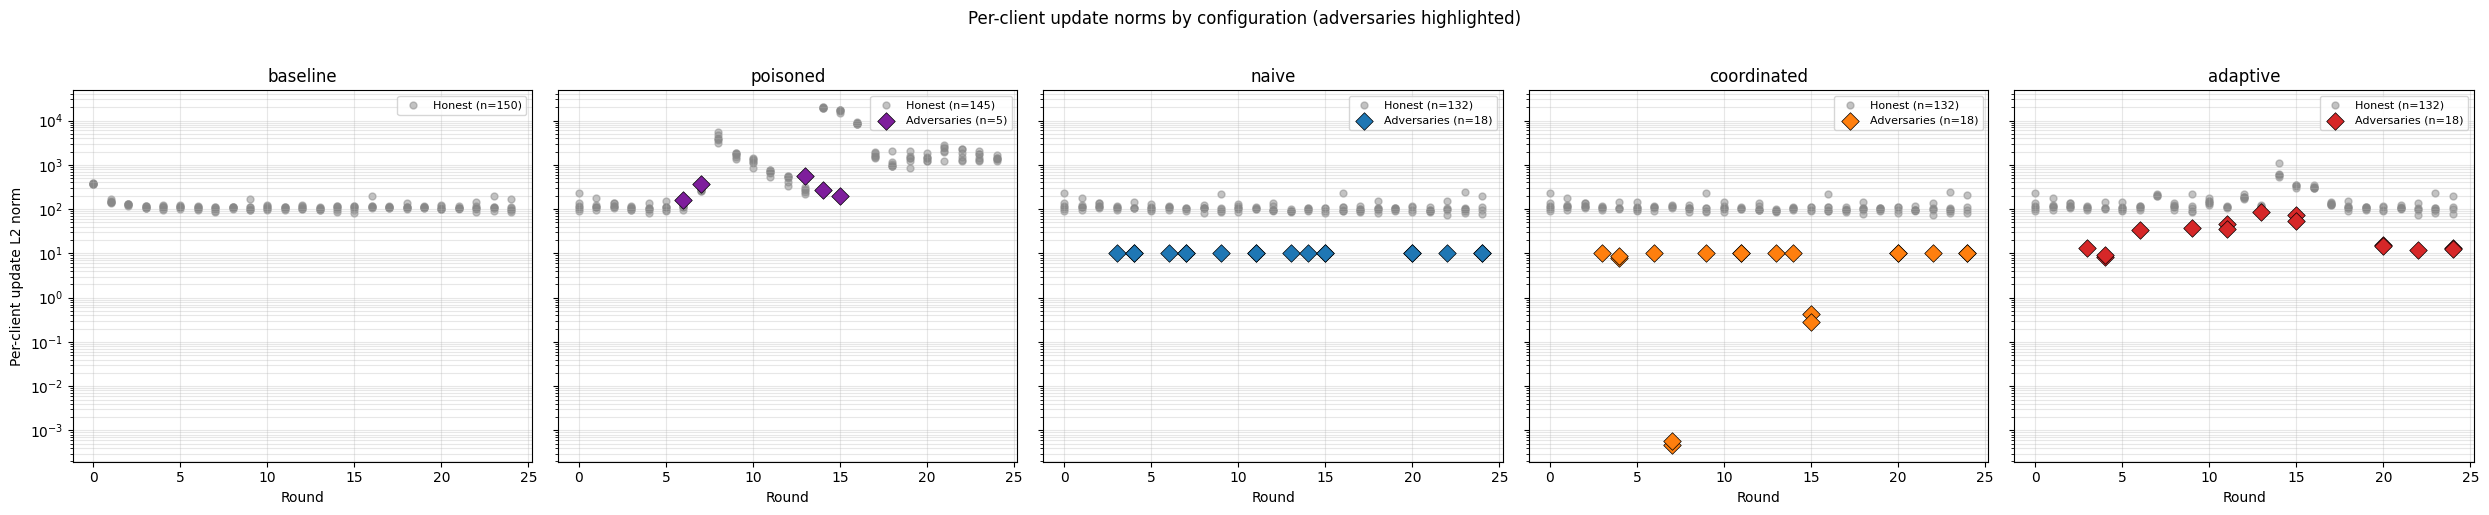

Saved ./figures/distributed_full_scatter.pdf and .png


In [25]:
import matplotlib.pyplot as plt
import os

if not all_runs:
    print('No histories available; skipping scatter.')
else:
    _n = len(all_runs)
    fig, axes = plt.subplots(1, _n, figsize=(5 * _n, 5), sharey=True)
    if _n == 1:
        axes = [axes]
    for ax, (_name, _run) in zip(axes, all_runs.items()):
        _m = _run['metrics']
        _norms = _m.get('client_norms', [])
        _is_adv = _m.get('client_is_adversary', [])
        _hx, _hy, _ax_, _ay = [], [], [], []
        for _r, (_row_n, _row_a) in enumerate(zip(_norms, _is_adv)):
            for _norm, _adv in zip(_row_n, _row_a):
                if _adv:
                    _ax_.append(_r); _ay.append(_norm)
                else:
                    _hx.append(_r); _hy.append(_norm)
        ax.scatter(_hx, _hy, color='#888888', alpha=0.5, s=25, label=f'Honest (n={len(_hy)})')
        if _ax_:
            ax.scatter(_ax_, _ay, color=RUN_COLORS.get(_name, '#d62728'), marker='D', s=80,
                       edgecolors='black', linewidths=0.5, zorder=5,
                       label=f'Adversaries (n={len(_ay)})')
        ax.set_title(_name)
        ax.set_xlabel('Round')
        ax.set_yscale('log')
        ax.grid(alpha=0.3, which='both')
        ax.legend(loc='best', fontsize=8)
    axes[0].set_ylabel('Per-client update L2 norm')
    fig.suptitle('Per-client update norms by configuration (adversaries highlighted)', y=1.02)
    plt.tight_layout()
    if not os.path.exists('./figures'):
        os.mkdir('./figures')
    plt.savefig('./figures/distributed_full_scatter.pdf', bbox_inches='tight')
    plt.savefig('./figures/distributed_full_scatter.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved ./figures/distributed_full_scatter.pdf and .png')